## Dimensionality reduction

In [ ]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
from scipy.stats import median_abs_deviation
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri, pandas2ri
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse import issparse
import rpy2.robjects as ro
import rpy2.robjects.packages as rpackages
from rpy2.robjects import r
import harmonypy as hm
import pandas as pd
import random


## set global random seed to 42

In [36]:
sc.settings.seed = 42

In [ ]:
np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

In [4]:
adata = sc.read_h5ad("/projects/circ_iri/work/sc_analysis/dim_reduction/adata_concat_dim_reduction.h5ad", chunk_size = 20000)

## Harmony - Batch Correction

In [37]:
# Get PCs from the AnnData object
pcs = adata.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

(127419, 200)


In [6]:
adata.obs.columns

Index(['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier',
       'mt_outlier', 'soupx_groups', 'scDblFinder_score', 'scDblFinder_class',
       'sample', 'condition', 'size_factors'],
      dtype='object')

In [38]:
# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs, adata.obs, "sample")

2026-04-20 11:29:53,139 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-04-20 11:29:53,140 - harmonypy - INFO -   Parameters:
2026-04-20 11:29:53,141 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-20 11:29:53,142 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-20 11:29:53,143 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-20 11:29:53,143 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-20 11:29:53,144 - harmonypy - INFO -     nclust: 100
2026-04-20 11:29:53,145 - harmonypy - INFO -     block_size: 0.05
2026-04-20 11:29:53,146 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-04-20 11:29:53,146 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-04-20 11:29:53,147 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-20 11:29:53,148 - harmonypy - INFO -     verbose: True
2026-04-20 11:29:53,148 - harmonypy - INFO -     random_state: 0
2026-04-20 11:29:53,149 - harmonypy - INFO -   Data: 200 PCs × 127419 cell

2026-04-20 11:29:53,451 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-20 11:30:01,749 - harmonypy - INFO - KMeans initialization complete.
2026-04-20 11:30:01,909 - harmonypy - INFO - Iteration 1 of 10
2026-04-20 11:30:13,004 - harmonypy - INFO - Iteration 2 of 10
2026-04-20 11:30:23,039 - harmonypy - INFO - Iteration 3 of 10
2026-04-20 11:30:33,576 - harmonypy - INFO - Iteration 4 of 10
2026-04-20 11:30:41,587 - harmonypy - INFO - Iteration 5 of 10
2026-04-20 11:30:49,356 - harmonypy - INFO - Iteration 6 of 10
2026-04-20 11:30:57,017 - harmonypy - INFO - Iteration 7 of 10
2026-04-20 11:31:04,942 - harmonypy - INFO - Iteration 8 of 10
2026-04-20 11:31:12,202 - harmonypy - INFO - Iteration 9 of 10
2026-04-20 11:31:19,530 - harmonypy - INFO - Iteration 10 of 10
2026-04-20 11:31:26,912 - harmonypy - INFO - Stopped before convergence


In [39]:
# Store corrected PCs back in the AnnData object
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr

## UMAP - batch corrected


In [44]:
# Use harmonized PCs for downstream analysis
sc.pp.neighbors(adata, use_rep='X_pca_harmony', random_state=42)
sc.tl.umap(adata, random_state=42)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2, random_state=42)

In [10]:
adata.write("/projects/circ_iri/work/sc_analysis/dim_reduction_batch_corrected/adata_concat_dim_reduction_batch_corrected.h5ad")

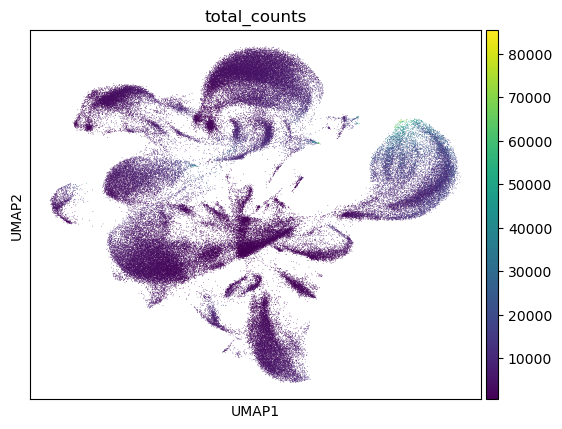

In [41]:
sc.pl.umap(adata, color="total_counts")

In [12]:
plt.savefig("/projects/circ_iri/work/sc_analysis/dim_reduction_batch_corrected/UMAP_total_counts_batch_corrected_plot.png")

<Figure size 640x480 with 0 Axes>

## Inspecting quality control metrics - batch corrected

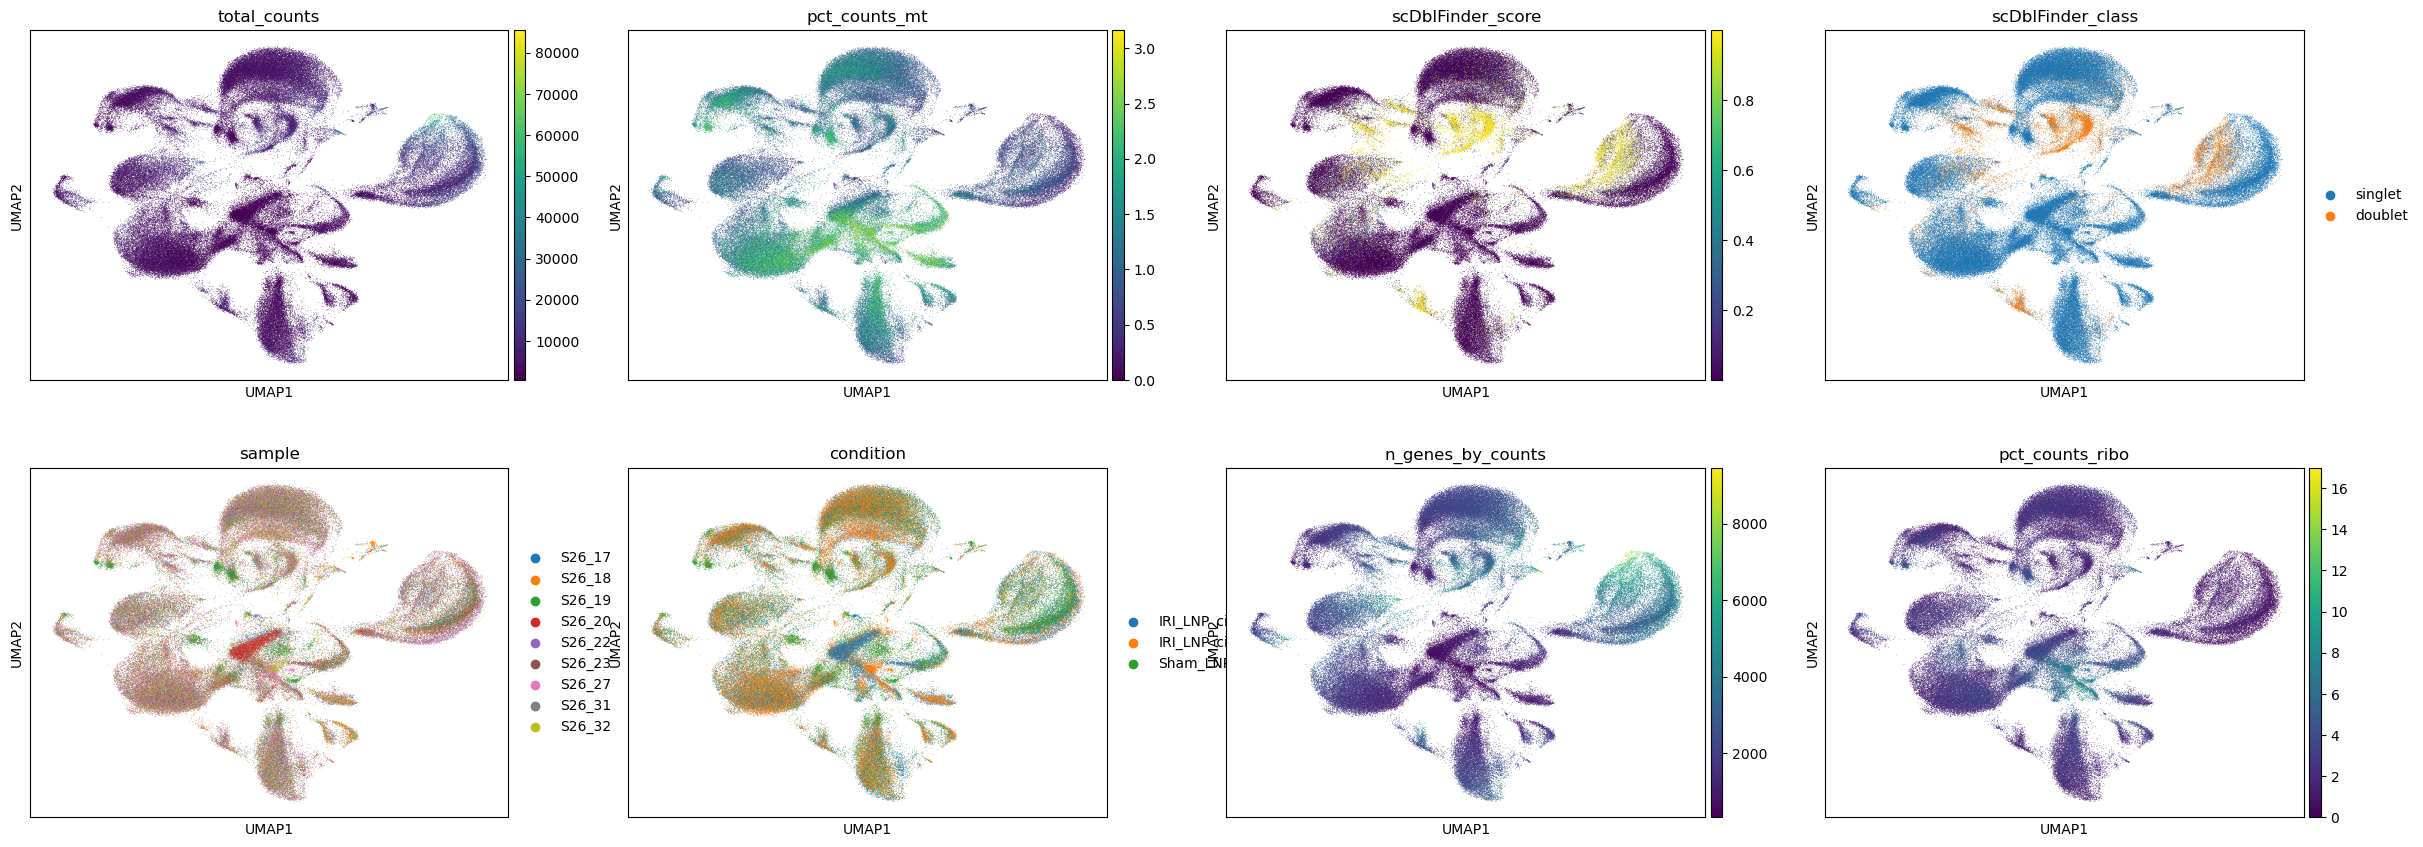

In [51]:
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "scDblFinder_score", "scDblFinder_class", "sample", "condition", "n_genes_by_counts", "pct_counts_ribo"],
)

In [14]:
plt.savefig("/projects/circ_iri/work/sc_analysis/dim_reduction_batch_corrected/UMAP_overview_batch_corrected_plot.png")

<Figure size 640x480 with 0 Axes>

## Clustering - batch corrected

In [42]:
sc.tl.leiden(
    adata, key_added="leiden_res0_25", resolution=0.25, flavor="igraph", n_iterations=2
)
sc.tl.leiden(
    adata, key_added="leiden_res0_5", resolution=0.5, flavor="igraph", n_iterations=2
)
sc.tl.leiden(
    adata, key_added="leiden_res1", resolution=1.0, flavor="igraph", n_iterations=2
)
sc.tl.leiden(
    adata, key_added="leiden_res2", resolution=2.0, flavor="igraph", n_iterations=2
)

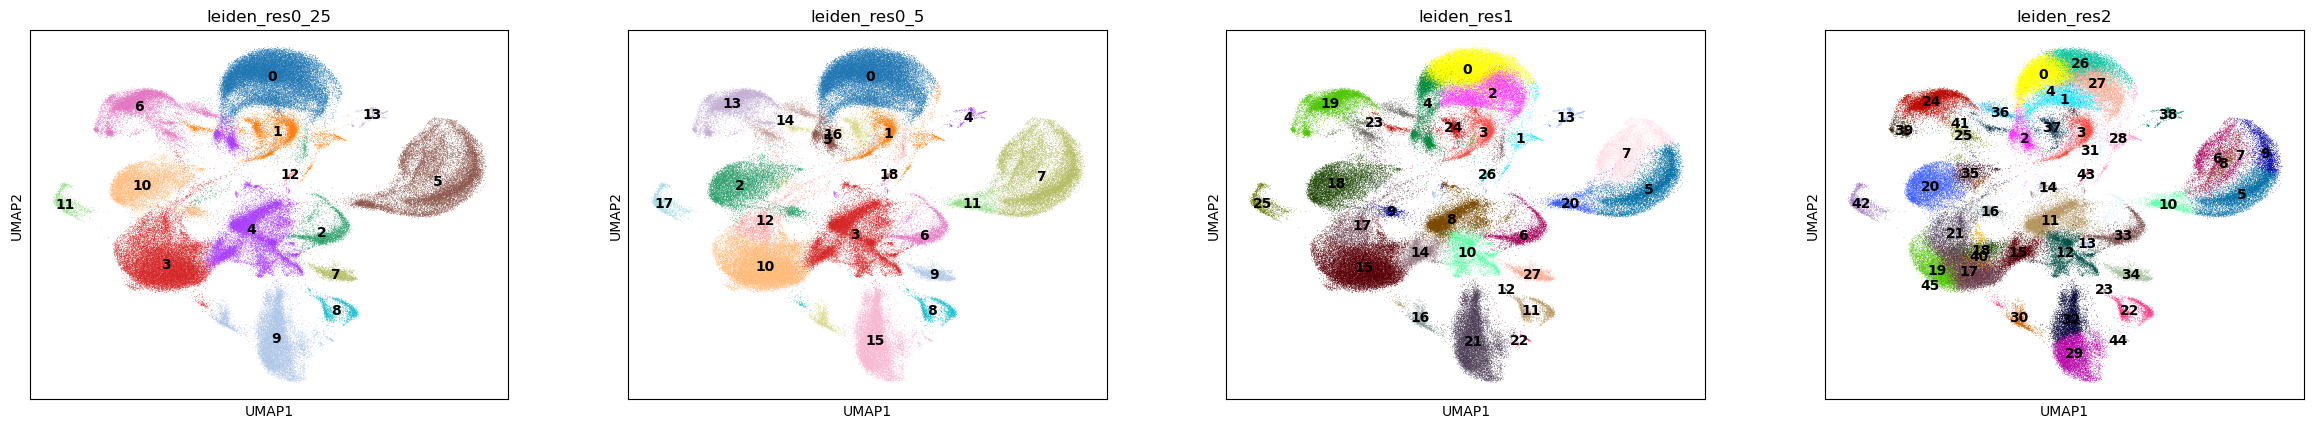

In [52]:
sc.pl.umap(
    adata,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1", "leiden_res2"],
    legend_loc="on data",
)

In [17]:
plt.savefig("/projects/circ_iri/work/sc_analysis/clustering_batch_corrected/UMAP_celltypes_different_res_batch_corrected_plot.png")

<Figure size 640x480 with 0 Axes>

## Cluster for S26_20 in more detail 

In [19]:
cluster = "8"

subset = adata.obs[adata.obs["leiden_res2"] == cluster]

In [ ]:
metrics = [
    "total_counts",
    "n_genes_by_counts",
    "pct_counts_ribo",
    "pct_counts_mt"
]

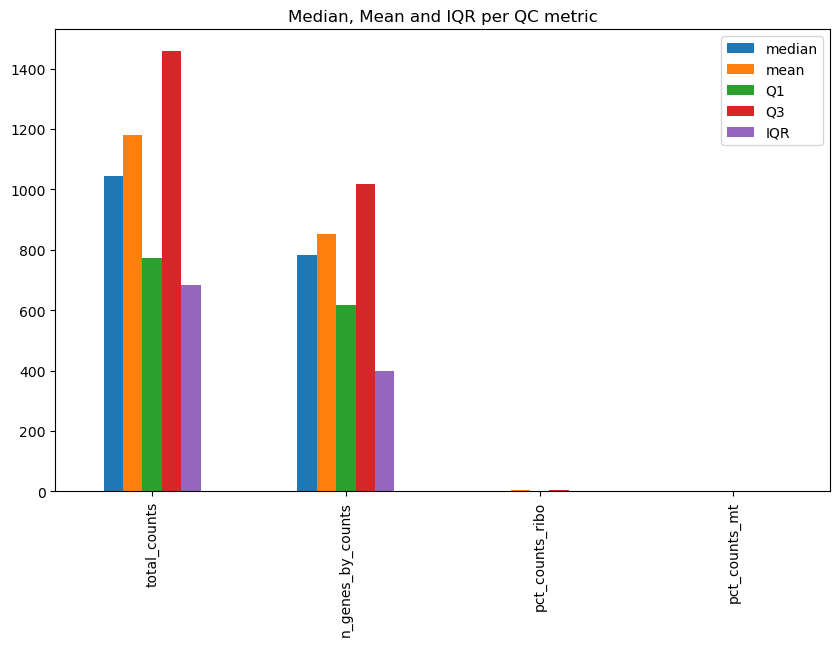

In [23]:
summary = pd.DataFrame({
    "median": subset[metrics].median(),
    "mean": subset[metrics].mean(),
    "Q1": subset[metrics].quantile(0.25),
    "Q3": subset[metrics].quantile(0.75)
})

summary["IQR"] = summary["Q3"] - summary["Q1"]

summary.plot(kind="bar", figsize=(10,6))


plt.title("Median, Mean and IQR per QC metric")
plt.show()

## Comparison to different Leiden-Cluster

,leiden_res2,total_counts,n_genes_by_counts,pct_counts_ribo,pct_counts_mt
AAACCAAAGCGCCTGA-1-S26_17,0,2887.0,1741,1.627988,0.969865
AAACCAAAGGCGAGAC-1-S26_17,0,2360.0,1458,1.652542,1.355932
AAACCAAAGGCTCCGA-1-S26_17,6,5668.0,2520,1.111503,0.846860
AAACCAAAGGTGCAGA-1-S26_17,8,1103.0,886,2.266546,1.450589
AAACCAAAGTCGCATA-1-S26_17,15,1730.0,1109,2.774566,1.849711
...,...,...,...,...,...
TGTGTACGTTAGCCCA-1-S26_32,15,1182.0,755,0.423012,0.592217
TGTGTTAGTAGGTCCC-1-S26_32,1,4861.0,2209,2.098334,0.781732
TGTGTTAGTATGTCCG-1-S26_32,29,2239.0,1395,2.143814,1.652524
TGTGTTAGTTAACCCG-1-S26_32,11,1021.0,721,6.072478,2.056807


In [46]:
df_long

,leiden_res2,metric,value
0,0,total_counts,2887.000000
1,0,total_counts,2360.000000
2,6,total_counts,5668.000000
3,8,total_counts,1103.000000
4,15,total_counts,1730.000000
...,...,...,...
509671,15,pct_counts_mt,0.592217
509672,1,pct_counts_mt,0.781732
509673,29,pct_counts_mt,1.652524
509674,11,pct_counts_mt,2.056807


In [53]:


df = adata.obs[["leiden_res1"] + metrics].copy()

df_long = df.melt(
    id_vars="leiden_res1",
    value_vars=metrics,
    var_name="metric",
    value_name="value"
)

/tmp/ipykernel_3354065/1773422064.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


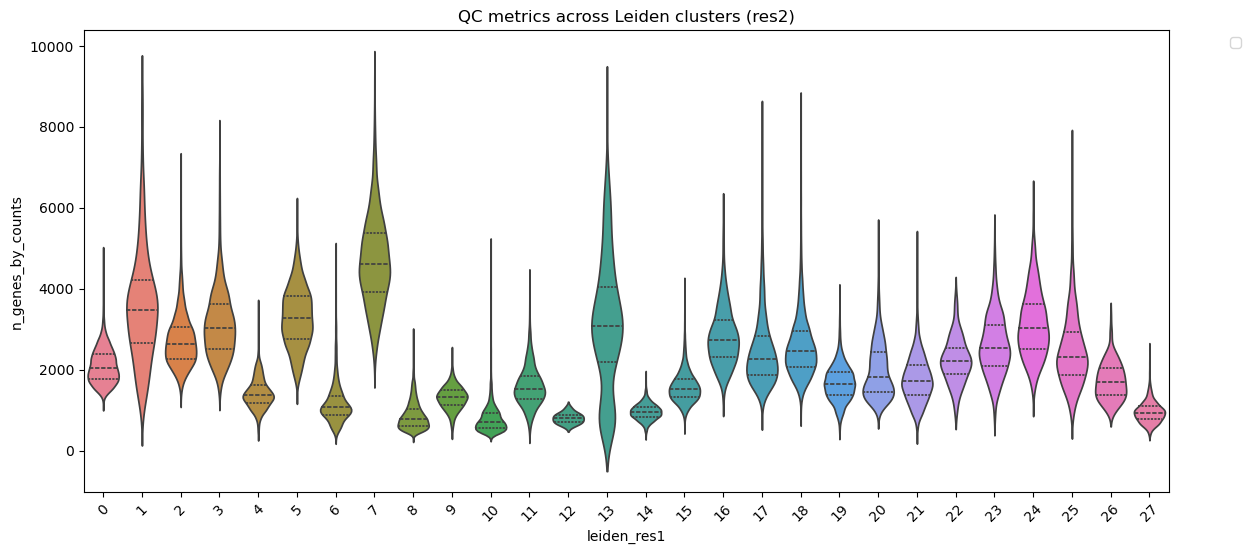

In [54]:
plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x="leiden_res1",
    y="n_genes_by_counts",
    hue="leiden_res1",
    split=False,
    inner="quartile"
)

plt.xticks(rotation=45)
plt.title("QC metrics across Leiden clusters (res2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

/tmp/ipykernel_3354065/2887287929.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


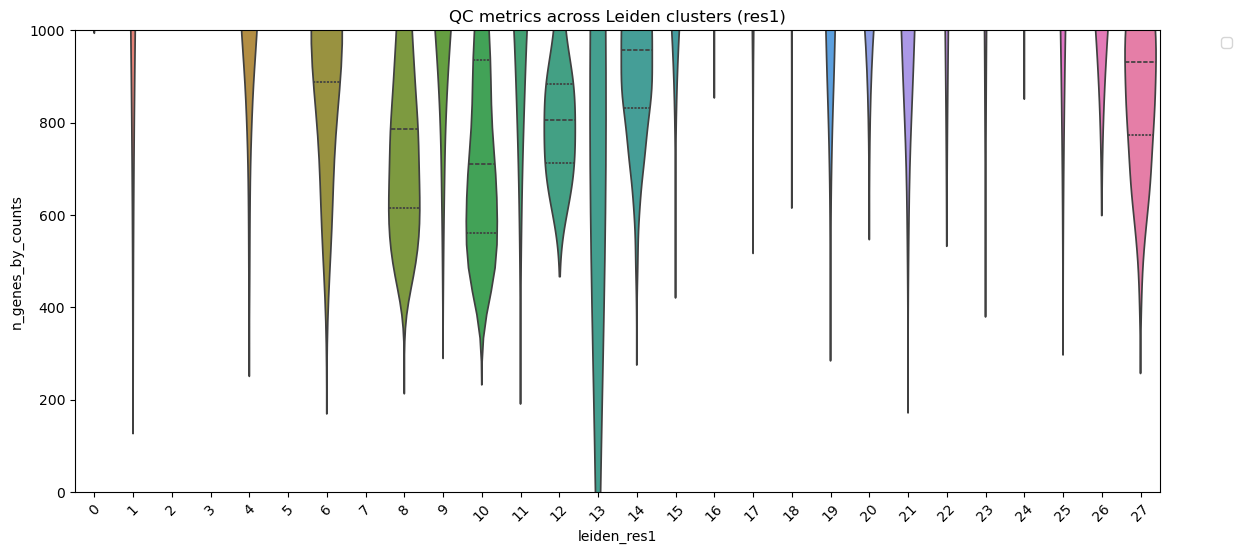

In [59]:
plt.figure(figsize=(14,6))

ax = sns.violinplot(
    data=df,
    x="leiden_res1",
    y="n_genes_by_counts",
    hue="leiden_res1",
    split=False,
    inner="quartile"
)
ax.set_ylim(0, 1000)
plt.xticks(rotation=45)
plt.title("QC metrics across Leiden clusters (res1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

/tmp/ipykernel_3354065/3887857026.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


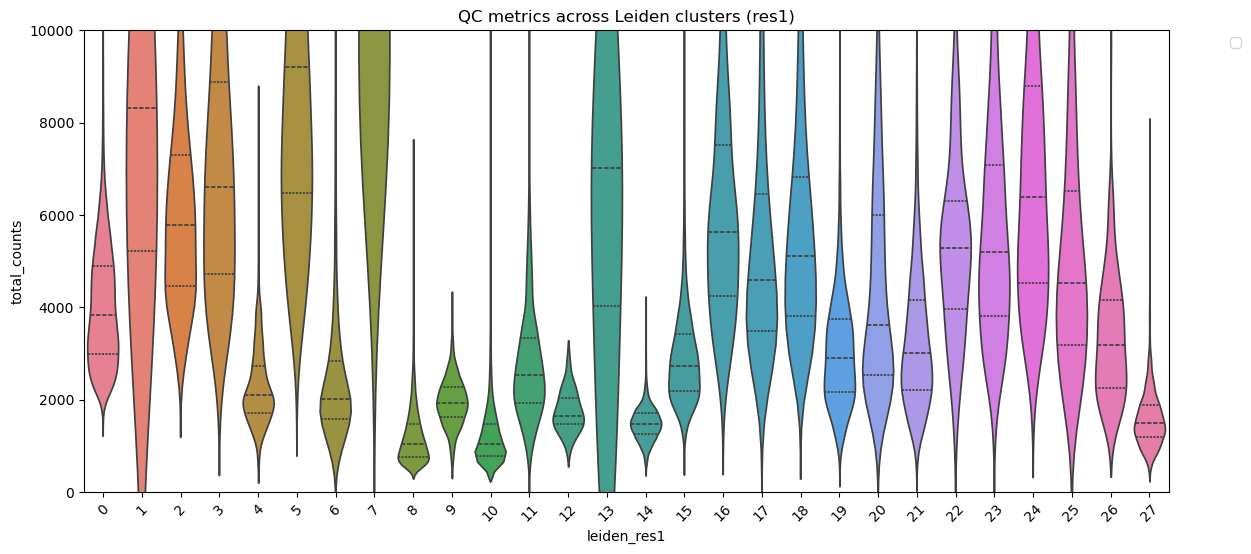

In [57]:
plt.figure(figsize=(14,6))

ax = sns.violinplot(
    data=df,
    x="leiden_res1",
    y="total_counts",
    hue="leiden_res1",
    split=False,
    inner="quartile"
)

ax.set_ylim(0, 10000)

plt.xticks(rotation=45)
plt.title("QC metrics across Leiden clusters (res1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

/tmp/ipykernel_3354065/685593107.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


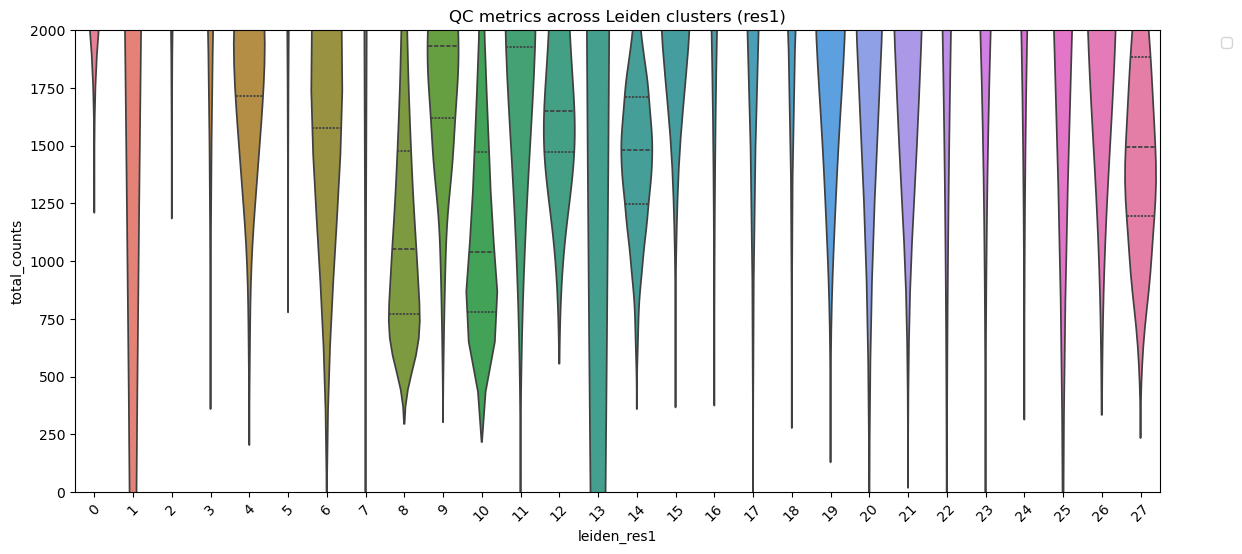

In [58]:
plt.figure(figsize=(14,6))

ax = sns.violinplot(
    data=df,
    x="leiden_res1",
    y="total_counts",
    hue="leiden_res1",
    split=False,
    inner="quartile"
)

ax.set_ylim(0, 2000)

plt.xticks(rotation=45)
plt.title("QC metrics across Leiden clusters (res1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [35]:
plt.savefig("/projects/circ_iri/work/sc_analysis/clustering_batch_corrected/Leidenalgorithm_res2_comparison_batch_corrected_plot.png")

<Figure size 640x480 with 0 Axes>

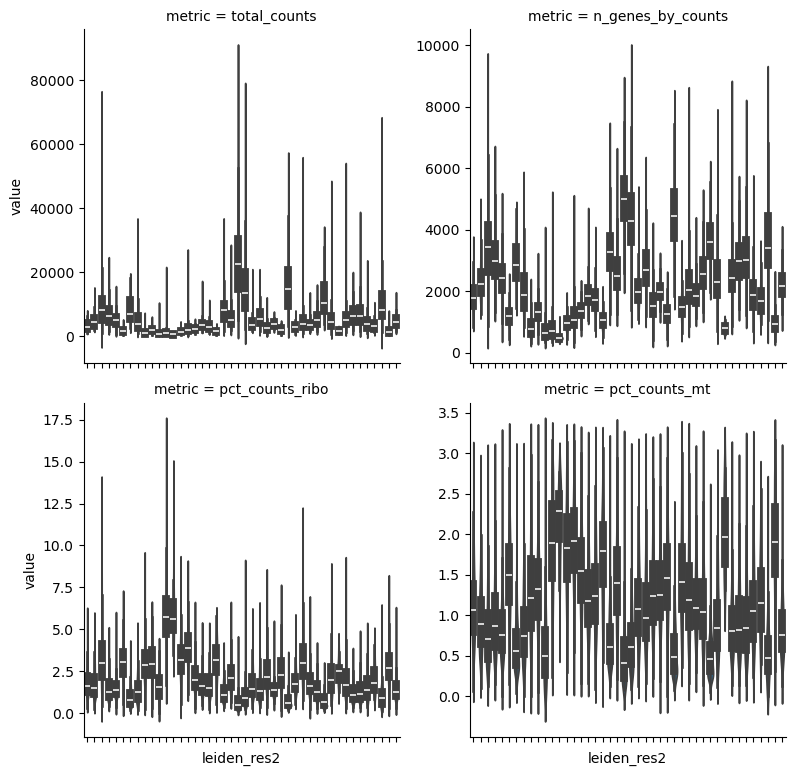

In [34]:
g = sns.catplot(
    data=df_long,
    x="leiden_res2",
    y="value",
    col="metric",
    kind="violin",
    col_wrap=2,
    sharey=False,
    height=4
)

g.set_xticklabels(rotation=90)
plt.show()

## Markergenes

## Paper1

In [ ]:
# paper 1:

marker_genes_paper1 = {
    "endothelial_cells": ["Pecam1", "Vwf", "Dcn"],
    "ventricular_cardiomyocytes": ["Myh7", "Myl2", "Fhl2"],
    "fibroblasts": ["Dcn", "Gsn", "Pdgfra"],
    "pericytes": ["Rgs5", "Abcc9", "Kcnj8"],
    "mesothelial_cells": ["Msln", "Wt1", "Bnc1"],
    "myeloid_cells": ["C1qa"],
    "neurons": ["Plp1"]
}

### UMAP

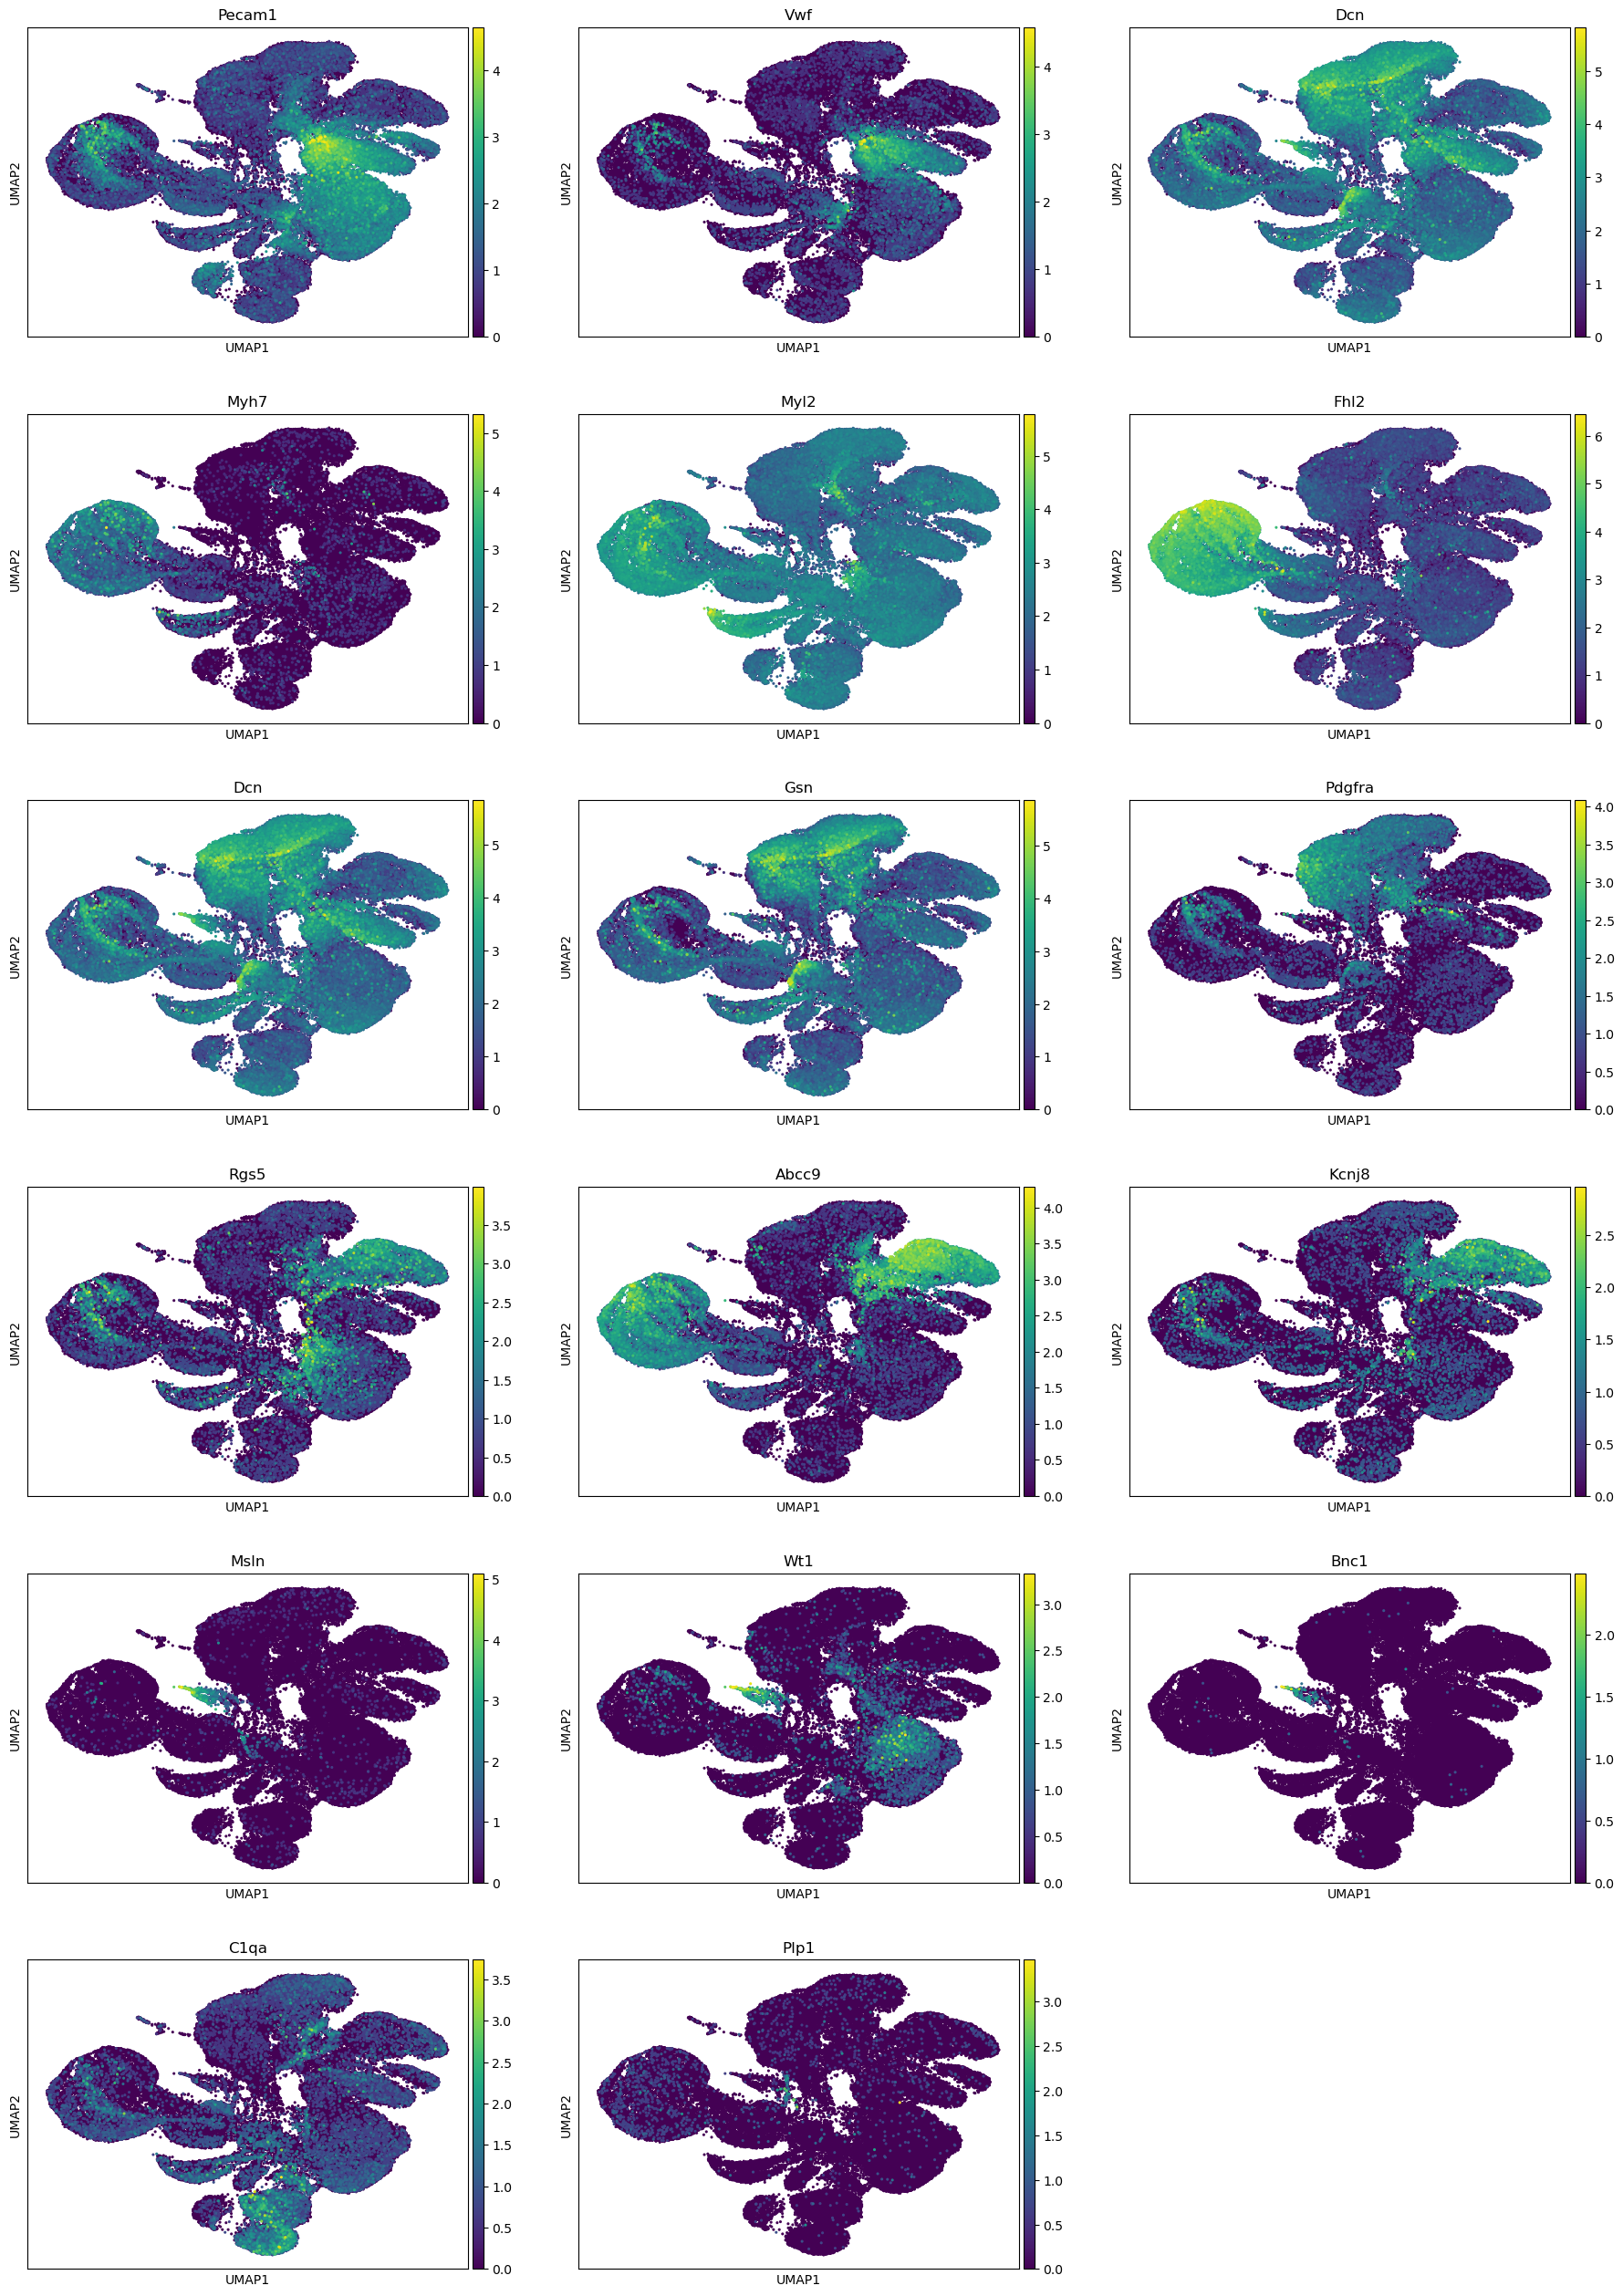

In [ ]:
# Flatten gene list (for Scanpy plotting)
all_genes = sorted(set(g for genes in marker_genes_paper1.values() for g in genes))

# enforce NON-alphabetical order (your defined order)
ordered_genes = []
for cell_type in marker_genes_paper1:
    ordered_genes.extend(marker_genes_paper1[cell_type])

# keep only genes present in dataset, preserving order
ordered_genes = [g for g in ordered_genes if g in adata.var_names]

# UMAP feature plots in exact order
sc.pl.umap(
    adata,
    color=ordered_genes,
    ncols=3,
    cmap="viridis",
    size=20
)



In [ ]:
plt.savefig("/projects/circ_iri/work/sc_analysis/clustering_batch_corrected/UMAP_markergenes_paper1_batch_corrected_plot.png")

### Dotplot

In [ ]:
# 4) Dotplot grouped by Leiden clusters (0–15)
sc.pl.dotplot(
    adata,
    var_names=marker_genes_paper1,
    groupby="leiden_res0_25",
    standard_scale="var",
    dendrogram=False
)

In [ ]:
plt.savefig("/projects/circ_iri/work/sc_analysis/clustering_batch_corrected/dotplot_markergenes_paper1_batch_corrected_plot.png")

## Paper2

In [ ]:
marker_genes_paper2 = {
    "EC": ["Plvap", "Cdh5", "Npr3"],
    "vCM": ["Myl2", "Tnnt2", "Myh7"],
    "EndMT": ["Cthrc1", "Postn", "Twist1"],
    "aCM": ["Myh6", "Myl7", "Myl1"],  # inferred from cardiac marker structure in panel
    "Epi": ["Upk3b", "Upk1b", "Msln"],
    "VSMC": ["Fbln5", "Cxcl12", "Eln"],
    "EPDC": ["Tcf21","Pdgfra", "Dcn"],
    "Ery": ["Hbb-bt", "Hba-a2", "Alas2"],
    "SHF": ["Tbx5", "Osr1",],
    "Mac": ["C1qa", "C1qb", "Ccl4"]
}

## UMAP

In [ ]:
# Flatten gene list (for Scanpy plotting)
all_genes = sorted(set(g for genes in marker_genes_paper2.values() for g in genes))

# enforce NON-alphabetical order (your defined order)
ordered_genes = []
for cell_type in marker_genes_paper2:
    ordered_genes.extend(marker_genes_paper2[cell_type])

# keep only genes present in dataset, preserving order
ordered_genes = [g for g in ordered_genes if g in adata.var_names]

# 1) UMAP colored by each gene (feature plots)
sc.pl.umap(
    adata,
    color=ordered_genes,
    ncols=3,
    cmap="viridis",
    size=20
)

In [ ]:
plt.savefig("/projects/circ_iri/work/sc_analysis/clustering_batch_corrected/UMAP_markergenes_paper2_batch_corrected_plot.png")

### Dotplot

In [ ]:
# 4) Dotplot grouped by Leiden clusters (0–15)
sc.pl.dotplot(
    adata,
    var_names=marker_genes_paper2,
    groupby="leiden_res0_25",
    standard_scale="var",
    dendrogram=False
)

In [ ]:
plt.savefig("/projects/circ_iri/work/sc_analysis/clustering_batch_corrected/dotplot_markergenes_paper2_batch_corrected_plot.png")